In [6]:
import pandas as pd
df = pd.read_csv('housing.csv')
print("İlk 5 satır")
display(df.head())

İlk 5 satır


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proxim

In [8]:
# 1. Eksik değerleri temizle 
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 2. Kategorik veriyi (ocean_proximity) sayısallaştır
df = pd.get_dummies(df, columns=['ocean_proximity'])

# 3. Kontrol et
print("Eksik değer sayısı:", df.isnull().sum().sum())
print("Yeni sütun sayısı:", df.shape[1])
display(df.head())

Eksik değer sayısı: 0
Yeni sütun sayısı: 14


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Özellikleri (X) ve hedefi (y) ayıralım
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 2. Eğitim ve test verisine bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest modelini kur ve eğit
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Tahmin yap
y_pred = rf_model.predict(X_test)

# 5. Performans sonuçlarını yazdır
print("--- Housing Price Prediction Performansı ---")
print(f"R2 Skoru (Başarı): {r2_score(y_test, y_pred):.2f}")
print(f"MSE (Hata Payı): {mean_squared_error(y_test, y_pred):.2f}")

--- Housing Price Prediction Performansı ---
R2 Skoru (Başarı): 0.82
MSE (Hata Payı): 2398820115.38


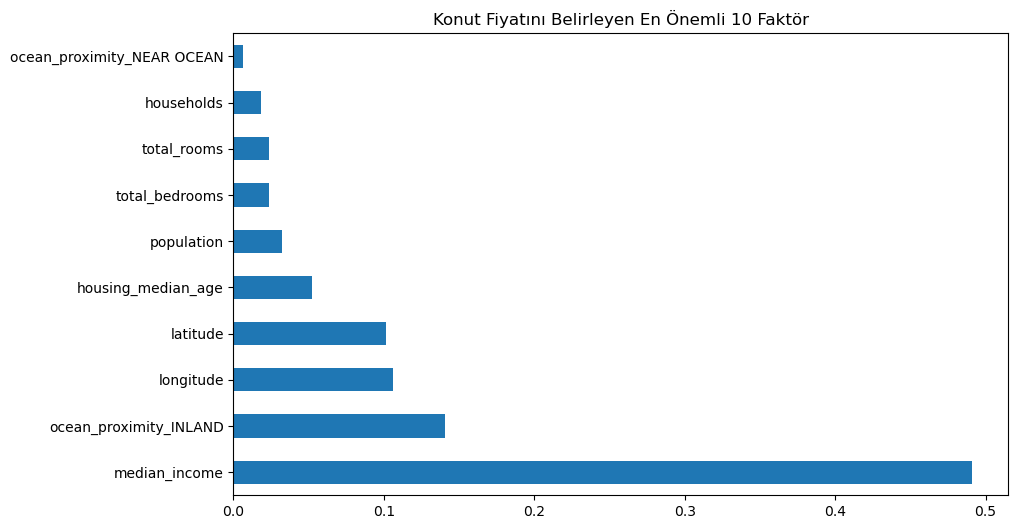

In [15]:
import matplotlib.pyplot as plt

# Özellik önemlerini alalım
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Görselleştir
feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
plt.title("Konut Fiyatını Belirleyen En Önemli 10 Faktör")
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

# 1. Parametre ızgarasını tanımla
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

# 2. GridSearchCV kurulumu
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='r2', verbose=2)

# 3. Eğitimi başlat
grid_search.fit(X_train, y_train)

# 4. En iyi sonuçları görüntüle
print("--- En İyi Parametreler ---")
print(grid_search.best_params_)

# 5. En iyi model ile yeni skor
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"\nOptimize Edilmiş R2 Skoru: {r2_score(y_test, y_pred_best):.2f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
--- En İyi Parametreler ---
{'max_depth': None, 'n_estimators': 200}

Optimize Edilmiş R2 Skoru: 0.82
